In [22]:
import sys
print(sys.executable)

/Users/sanulanawarathna/Documents/Vs Code/Finacial Forcasting using Time Series/.venv/bin/python


In [23]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import os
import datetime
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from scipy.optimize import brentq
from scipy.stats import norm
from scipy.interpolate import griddata
from datetime import datetime

In [24]:
# data = yf.download("AAPL", period="1y")
# plt.plot(data)
# data["Returns"] = data["Close"].pct_change()
# print(data[["Close", "Returns"]].head())
# data.to_csv("AAPL_data.csv")
data = pd.read_csv("appl.csv", parse_dates=True)
data = data.dropna()

## Testing Stationarity

ADF Statistic: -15.112920578526557
p-value: 7.650652461610084e-28
Critical Values: {'1%': np.float64(-3.456780859712), '5%': np.float64(-2.8731715065600003), '10%': np.float64(-2.572968544)}


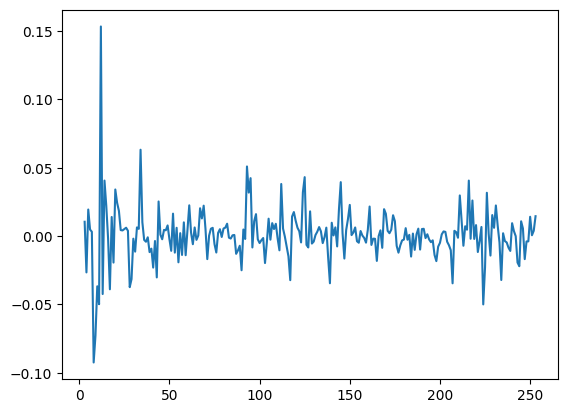

In [25]:
result = adfuller(data["Returns"])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])
plt.plot(data['Returns'])


## Realised Volatility 

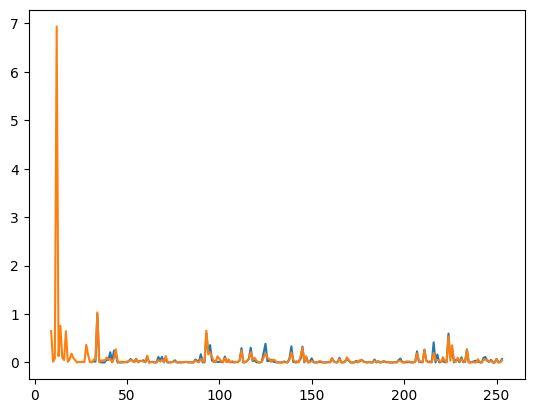

In [26]:
data['sq_dev_30'] = ( data['Returns']-data['Returns'].rolling(30).mean())**2*251
data['sq_dev_7'] = ( data['Returns']-data['Returns'].rolling(7).mean())**2*251

plt.plot(data['sq_dev_30'])
plt.plot(data['sq_dev_7'])


## Implied Volatility 

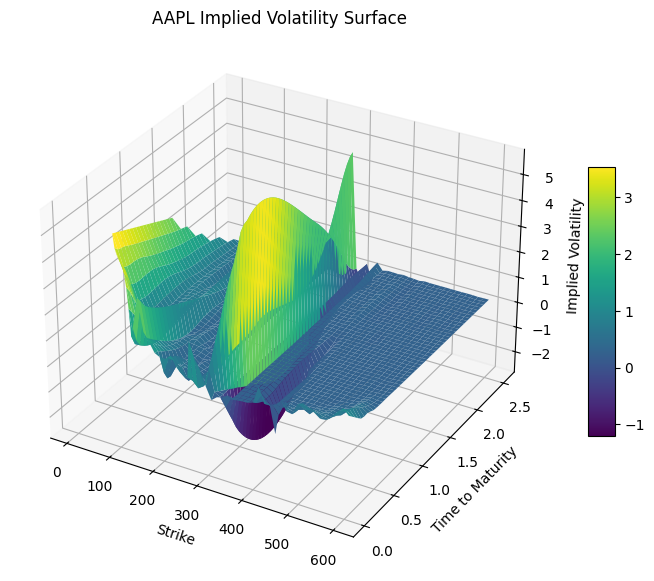

In [27]:
# Black-Scholes Call Price

def black_scholes_call(S, K, r, T, sigma):
    # Intrinsic value 
    if sigma <= 0 or T <= 0:
        return max(S - K, 0)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


# Implied Volatility Solver

def implied_volatility(C_market, S, K, r, T):

    if C_market <= 0:
        return np.nan

    try:
        return brentq(
            lambda sigma:
            black_scholes_call(S, K, r, T, sigma) - C_market,
            1e-6,
            5
        )
    except:
        return np.nan


# Download Option Data

ticker = yf.Ticker("AAPL")

S = ticker.history(period="1d")["Close"].iloc[-1]

r = 0.04      # approximate risk-free rate

today = datetime.today()

K_list = []
T_list = []
IV_list = []


# Loop Through Expiries

for expiry in ticker.options:

    expiry_date = datetime.strptime(expiry, "%Y-%m-%d")

    T = (expiry_date - today).days / 365

    if T <= 0:
        continue

    chain = ticker.option_chain(expiry)

    calls = chain.calls

    for _, row in calls.iterrows():

        K = row["strike"]
        market_price = row["lastPrice"]

        if np.isnan(market_price):
            continue

        iv = implied_volatility(
            market_price,
            S,
            K,
            r,
            T
        )

        if np.isnan(iv):
            continue

        K_list.append(K)
        T_list.append(T)
        IV_list.append(iv)

# Create Grid


K = np.array(K_list)
T = np.array(T_list)
IV = np.array(IV_list)

K_grid = np.linspace(K.min(), K.max(), 50)
T_grid = np.linspace(T.min(), T.max(), 50)

K_mesh, T_mesh = np.meshgrid(K_grid, T_grid)

IV_mesh = griddata(
    (K, T),
    IV,
    (K_mesh, T_mesh),
    method='cubic'
)


# Plot Surface

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    IV_mesh,
    cmap='viridis'
)

ax.set_xlabel("Strike")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Implied Volatility")

ax.set_title("AAPL Implied Volatility Surface")

fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()

## Implementing ARCH(1) model (Attempt 1)

[0,
 0,
 1.0507600802058805,
 -0.8902430166424183,
 5.1370009983700635,
 11.695353036566177,
 3.3654073763007233,
 -112.8969162443191,
 0.3736277158782921,
 750.6414566094102,
 1.2448645281526756,
 3827.4706337931216,
 23.48502219372395,
 -67386.28359704874,
 71.21019991304766,
 -152136.24507668763,
 536.4248423384878,
 979529.5529463828,
 -3533.516958113664,
 -8513712.222311933,
 32095.41356007287,
 33273684.85342447,
 -133834.85682168652,
 859430458.7346684,
 1276584.2842175711,
 -8615337785.691612,
 -9825562.77480241,
 20416409736.850357,
 -15086047.84807449,
 -200918473560.22916,
 113857231.77220555,
 -918465538181.5424,
 -268403461.56012803,
 -4193136352289.6826,
 2339397201.4733334,
 -11155847862151.078,
 -22469904929.19417,
 -4609734435251.351,
 152336755103.88144,
 -13793687079183.055,
 518444635253.7526,
 -106899549238287.4,
 -2572837708000.974,
 -502928587513138.06,
 -10191681277439.754,
 3836867284410982.5,
 75528761105477.02,
 -4.081915713494536e+16,
 -418794001150180.56,
 

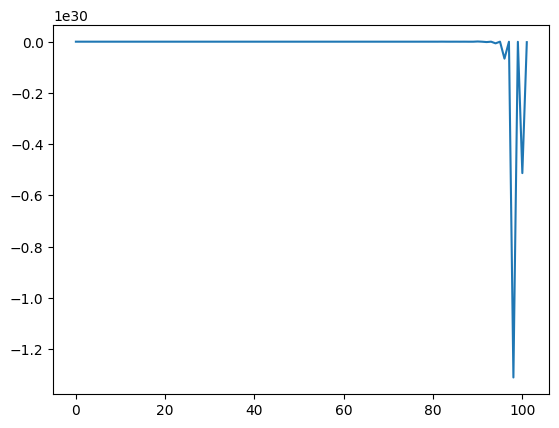

In [28]:
def arch_model(mew,alpha):
    y_t = [0]
    sigma_t = 0
    epsilon = [0]
    
    for i in range(100):
        z_t = np.random.normal(0,1)
        sigma_t = (alpha + np.random.randint(100)*epsilon[i-1]**2)**0.5
        epsilon.append(z_t*sigma_t)
    
    for x in epsilon:
        y_t.append(mew+x)
   
    plt.plot(y_t)
    plt.show
    return y_t
arch_model(0,1)




